In [10]:
# 🔧 Celda 1: Importar + Matriz Base

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu

print("=" * 60)
print("SEMANA 2: FACTORIZACIÓN (QR, LU, CHOLESKY)")
print("=" * 60)

# Matriz base para toda la semana
A = np.array([[4, 3], 
              [6, 3]], dtype=float)

print("\nMatriz A (usaremos esta en todo):")
print(A)


SEMANA 2: FACTORIZACIÓN (QR, LU, CHOLESKY)

Matriz A (usaremos esta en todo):
[[4. 3.]
 [6. 3.]]


In [2]:
# 🔹 Celda 2: QR Decomposition

print("\n" + "=" * 60)
print("1️⃣ QR DECOMPOSITION")
print("=" * 60)

# QR: A = Q @ R
# Q = matriz ortogonal (columnas perpendiculares)
# R = matriz triangular superior

Q, R = np.linalg.qr(A)

print("\nQ (matriz ortogonal):")
print(Q)
print("\nR (triangular superior):")
print(R)

# Verificación: Q @ R = A
A_reconstructed = Q @ R
print("\n✅ Verificación: Q @ R")
print(A_reconstructed)
print("Error:", np.max(np.abs(A - A_reconstructed)))

# Propiedad: Q^T @ Q = I (identidad)
print("\n🔍 Propiedad ortogonal: Q^T @ Q")
print(Q.T @ Q)  # Debería ser [[1, 0], [0, 1]]



1️⃣ QR DECOMPOSITION

Q (matriz ortogonal):
[[-0.5547002  -0.83205029]
 [-0.83205029  0.5547002 ]]

R (triangular superior):
[[-7.21110255 -4.16025147]
 [ 0.         -0.83205029]]

✅ Verificación: Q @ R
[[4. 3.]
 [6. 3.]]
Error: 8.881784197001252e-16

🔍 Propiedad ortogonal: Q^T @ Q
[[ 1.0000000e+00 -1.0499512e-17]
 [-1.0499512e-17  1.0000000e+00]]


In [4]:
# 🔹 Celda 3: LU Decomposition

print("\n" + "=" * 60)
print("2️⃣ LU DECOMPOSITION")
print("=" * 60)

# LU: A = L @ U
# L = matriz triangular inferior (lower)
# U = matriz triangular superior (upper)

from scipy.linalg import lu

from scipy.linalg import lu
P, L, U = lu(A)  # ✅ CORRECTO

print("\nP (permutación):")
print(P)
print("\nL (triangular inferior):")
print(L)
print("\nU (triangular superior):")
print(U)

# Verificación: P @ A = L @ U
A_reconstructed = P.T @ L @ U
print("\n✅ Verificación: P^T @ L @ U")
print(A_reconstructed)
print("Error:", np.max(np.abs(A - A_reconstructed)))

# Uso: resolver Ax = b
print("\n🎯 Usa LU para resolver Ax = b:")
b = np.array([1, 2])
x = np.linalg.solve(A, b)
print(f"Si b = {b}, entonces x = {x}")
print(f"Verificación A @ x = {A @ x} (debería ser {b})")



2️⃣ LU DECOMPOSITION

P (permutación):
[[0. 1.]
 [1. 0.]]

L (triangular inferior):
[[1.         0.        ]
 [0.66666667 1.        ]]

U (triangular superior):
[[6. 3.]
 [0. 1.]]

✅ Verificación: P^T @ L @ U
[[4. 3.]
 [6. 3.]]
Error: 0.0

🎯 Usa LU para resolver Ax = b:
Si b = [1 2], entonces x = [ 0.5        -0.33333333]
Verificación A @ x = [1. 2.] (debería ser [1 2])


In [5]:
# 🔹 Celda 4: Cholesky Decomposition

print("\n" + "=" * 60)
print("3️⃣ CHOLESKY DECOMPOSITION")
print("=" * 60)

# Cholesky: A = L @ L^T (solo para matrices simétricas positivas)
# Más rápido que LU, pero requiere condiciones especiales

# Creamos matriz simétrica positiva definida
A_sym = np.array([[4, 1], 
                  [1, 3]], dtype=float)

print("\nMatriz simétrica positiva definida:")
print(A_sym)

# Cholesky
L = np.linalg.cholesky(A_sym)

print("\nL (triangular inferior):")
print(L)

# Verificación: L @ L^T = A
A_reconstructed = L @ L.T
print("\n✅ Verificación: L @ L^T")
print(A_reconstructed)
print("Error:", np.max(np.abs(A_sym - A_reconstructed)))

print("\n💡 Ventajas de Cholesky:")
print("- Solo O(n³/6) operaciones (vs LU O(n³/3))")
print("- Para matrices simétricas positivas")
print("- Muy estable numéricamente")



3️⃣ CHOLESKY DECOMPOSITION

Matriz simétrica positiva definida:
[[4. 1.]
 [1. 3.]]

L (triangular inferior):
[[2.        0.       ]
 [0.5       1.6583124]]

✅ Verificación: L @ L^T
[[4. 1.]
 [1. 3.]]
Error: 0.0

💡 Ventajas de Cholesky:
- Solo O(n³/6) operaciones (vs LU O(n³/3))
- Para matrices simétricas positivas
- Muy estable numéricamente


In [6]:
# 🔹 Celda 5: Comparación

print("\n" + "=" * 60)
print("COMPARACIÓN DE FACTORIZACIONES")
print("=" * 60)

comparacion = """
FACTORIZACIÓN | FORMA       | MATRIZ REQ    | VELOCIDAD | USO
─────────────────────────────────────────────────────────────────
QR            | A = Q @ R   | Cualquiera    | O(n³)     | Least squares
LU            | A = L @ U   | Cuadrada      | O(n³/3)   | Resolver Ax=b
Cholesky      | A = L @ L^T | Sim. Pos.     | O(n³/6)   | Cov, ML
SVD           | A = U@Σ@V^T | Cualquiera    | O(n³)     | Rank, compresión
"""

print(comparacion)

print("\n🎯 Cuándo usar cada una:")
print("✓ QR: Cuando necesitas ortogonalización")
print("✓ LU: Para sistemas Ax=b en matrices cuadradas")
print("✓ Cholesky: Para matrices simétricas (MÁS RÁPIDO)")
print("✓ SVD: Cuando necesitas información de rango")



COMPARACIÓN DE FACTORIZACIONES

FACTORIZACIÓN | FORMA       | MATRIZ REQ    | VELOCIDAD | USO
─────────────────────────────────────────────────────────────────
QR            | A = Q @ R   | Cualquiera    | O(n³)     | Least squares
LU            | A = L @ U   | Cuadrada      | O(n³/3)   | Resolver Ax=b
Cholesky      | A = L @ L^T | Sim. Pos.     | O(n³/6)   | Cov, ML
SVD           | A = U@Σ@V^T | Cualquiera    | O(n³)     | Rank, compresión


🎯 Cuándo usar cada una:
✓ QR: Cuando necesitas ortogonalización
✓ LU: Para sistemas Ax=b en matrices cuadradas
✓ Cholesky: Para matrices simétricas (MÁS RÁPIDO)
✓ SVD: Cuando necesitas información de rango


In [8]:
# 🔹 Celda 6: Ejercicio - Resuelve Sistema

print("\n" + "=" * 60)
print("EJERCICIO: Resuelve Ax = b usando LU")
print("=" * 60)

# Sistema: 
# 4x + 3y = 10
# 6x + 3y = 12

A = np.array([[4, 3], [6, 3]], dtype=float)
b = np.array([10, 12])

print("\nSistema:")
print("4x + 3y = 10")
print("6x + 3y = 12")

# Método 1: Usando solve (internamente usa LU)
x_solve = np.linalg.solve(A, b)
print(f"\nSolución (np.linalg.solve): x = {x_solve}")

# Método 2: Manual con LU
from scipy.linalg import lu
P, L, U = lu(A)  # ✅ CORRECTO

# Resuelve L @ y = P @ b
y = np.linalg.solve(L, P @ b)

# Resuelve U @ x = y
x_manual = np.linalg.solve(U, y)
print(f"Solución (LU manual):       x = {x_manual}")

# Verificación
print(f"\nVerificación A @ x = {A @ x_solve}")
print(f"b = {b}")
print(f"✅ Correcto!" if np.allclose(A @ x_solve, b) else "❌ Incorrecto")



EJERCICIO: Resuelve Ax = b usando LU

Sistema:
4x + 3y = 10
6x + 3y = 12

Solución (np.linalg.solve): x = [1. 2.]
Solución (LU manual):       x = [1. 2.]

Verificación A @ x = [10. 12.]
b = [10 12]
✅ Correcto!


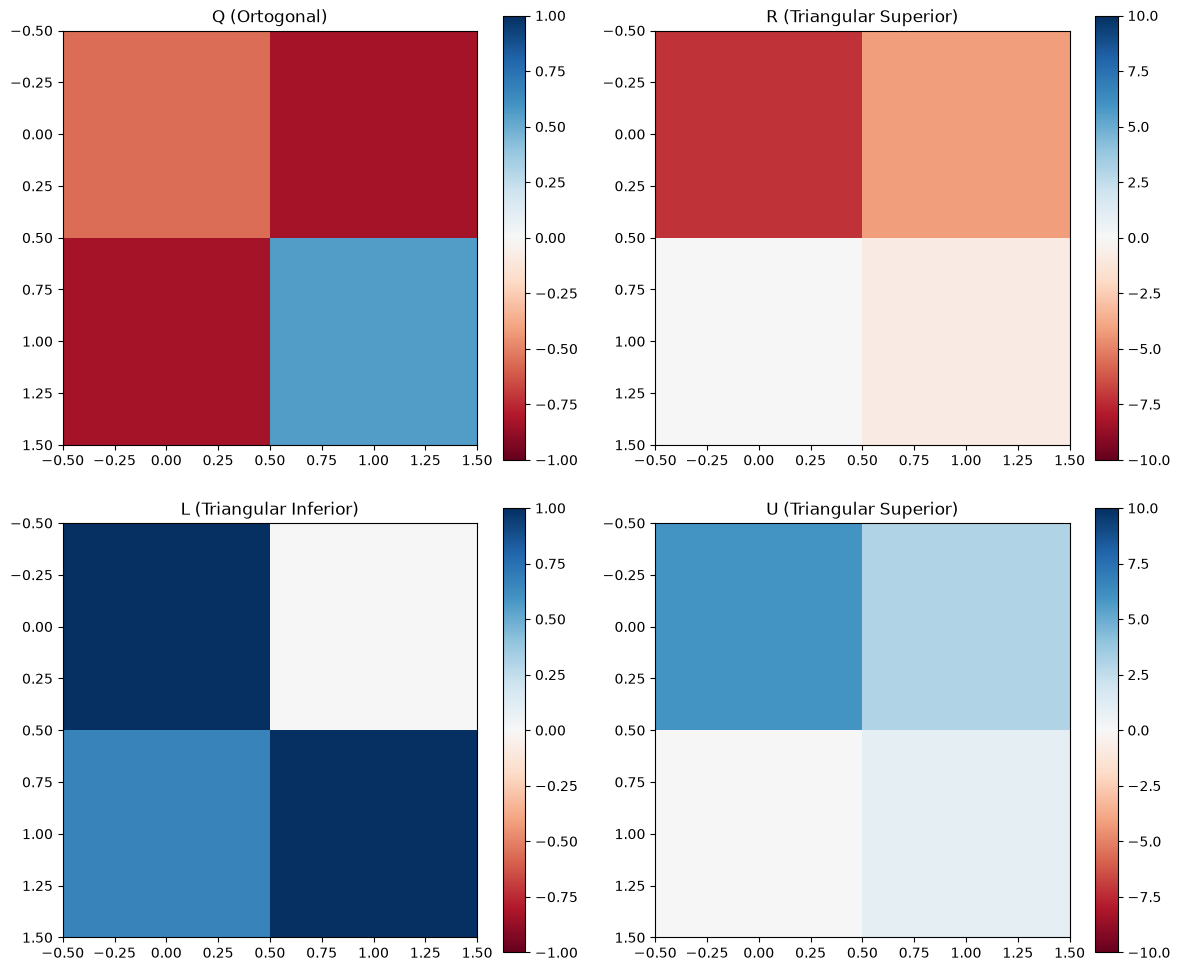

Visualización de factorizaciones


In [15]:
# 🔹 Celda 7: Visualización

from scipy.linalg import lu

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# QR
Q, R = np.linalg.qr(A)
im0 = axes[0, 0].imshow(Q, cmap='RdBu', vmin=-1, vmax=1)
axes[0, 0].set_title('Q (Ortogonal)')
plt.colorbar(im0, ax=axes[0, 0])

# R
im1 = axes[0, 1].imshow(R, cmap='RdBu', vmin=-10, vmax=10)
axes[0, 1].set_title('R (Triangular Superior)')
plt.colorbar(im1, ax=axes[0, 1])

# LU
P, L, U = lu(A)
im2 = axes[1, 0].imshow(L, cmap='RdBu', vmin=-1, vmax=1)
axes[1, 0].set_title('L (Triangular Inferior)')
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(U, cmap='RdBu', vmin=-10, vmax=10)
axes[1, 1].set_title('U (Triangular Superior)')
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Visualización de factorizaciones")


In [16]:
# ✅ Celda 8: Resumen Semana 2

print("""
✅ SEMANA 2 COMPLETADA

CONCEPTOS APRENDIDOS:
1. QR: Ortogonalización (matriz Q perpendicular + R triangular)
2. LU: Triangulación (L inferior + U superior, más rápido)
3. Cholesky: Especial para simétricas positivas (2x LU)

COMPARACIÓN:
- QR: General, ortogonal, O(n³)
- LU: Rápido, cuadrada, O(n³/3)
- Cholesky: Muy rápido, simétrica, O(n³/6)

APLICACIONES:
- Resolver sistemas Ax = b (LU)
- Least squares (QR)
- Covarianza, ML (Cholesky)
- Compression, rank (SVD)

🎯 PRÓXIMA SEMANA: Cálculo + Gradientes
""")



✅ SEMANA 2 COMPLETADA

CONCEPTOS APRENDIDOS:
1. QR: Ortogonalización (matriz Q perpendicular + R triangular)
2. LU: Triangulación (L inferior + U superior, más rápido)
3. Cholesky: Especial para simétricas positivas (2x LU)

COMPARACIÓN:
- QR: General, ortogonal, O(n³)
- LU: Rápido, cuadrada, O(n³/3)
- Cholesky: Muy rápido, simétrica, O(n³/6)

APLICACIONES:
- Resolver sistemas Ax = b (LU)
- Least squares (QR)
- Covarianza, ML (Cholesky)
- Compression, rank (SVD)

🎯 PRÓXIMA SEMANA: Cálculo + Gradientes

